# 15 minutes to Labcore

This introduction will guide you through using some of the basic features of Labcore. It consists of setting up a measurement using a sweep, saving and loading the data from storage, and analyzing and visualizing the data.

Our [user guide](user_guide.md) contains more detailed information on all these topics and more.

## Installing labcore

Labcore can be installed from a local clone:

```bash
pip install -e /path/to/labcore
```

Note: not yet available from PyPI. But coming soon! :)



## Importing the basics

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from labcore.measurement import sweep_parameter, record_as, independent, dependent
from labcore.measurement.storage import run_and_save_sweep

Now we'll walk through setting up a simple measurement. Measurement in labcore is built around sweeps, which allow you to vary parameters of your instruments and record data in a structured way with metadata.

We'll create a simple synthetic measurement where we sweep a parameter `x` and record a dependent variable `y` that is a sine function of `x` plus some noise. Sweeps consist of a *pointer* that defines the parameter to sweep, and an *action* that defines what to do at each step of the sweep.

To read a much more thorough guide on sweeps, see [here](../user_guide/measurement/sweep.md).

In [2]:
x = np.linspace(0, 5, 6)

def measure(x):
    return x, x**2 + np.random.normal(0, 0.1, size=x.shape)

# sweep = sweep_parameter('x', x,record_as(measure, independent('x', unit='seconds'), dependent('y', unit='meters')))

sweep = sweep_parameter(
    'x', x,
    record_as(
        measure,
        independent('x', unit='seconds'),
        dependent('y', unit='meters')
    )
)

print(f"Data specs: {sweep.get_data_specs()}")
print(sweep)

Data specs: (x, y(x))
array([0., 1., 2., 3., 4., 5.]) as {x} >> measure(x) as {x, y}
==> {x, y(x)}


In this example, we use `x` as our pointer, and our action will be to record `y` as a function of `x`. The {py:meth}`record_as <labcore.measurement.record.record_as>` function lets us keep a record of the data we measure, metadata such as units and descriptions, and the relationship between independent and dependent variables. By printing the sweep, we can see its structure. This doesn't actually perform the measurement yet; it just displays the framework.

The most basic way to perform the sweep is to simply iterate through and print the resultant data.

In [3]:
for data in sweep:
    print(data)

{'x': np.float64(0.0), 'y': np.float64(-0.15650391151752208)}
{'x': np.float64(1.0), 'y': np.float64(1.108156712883816)}
{'x': np.float64(2.0), 'y': np.float64(4.085215135282929)}
{'x': np.float64(3.0), 'y': np.float64(8.911130390668642)}
{'x': np.float64(4.0), 'y': np.float64(15.849892453443786)}
{'x': np.float64(5.0), 'y': np.float64(25.195899941024013)}


## Using DataDict to store data

For most uses, printing the data like above isn't a particularly great way to run a measurement or save data. A better method is to use the labcore {py:class}`DataDict <labcore.data.datadict.DataDict>` structure. This creates a structured record of the measurement we performed, is compatible with the rest of labcore, and is general enough to be used in conjunction with most other common libraries. More about {py:class}`DataDict <labcore.data.datadict.DataDict>` can be found [here](../user_guide/data/data_formats.md).

DataDicts are built on top of Python dictionaries, so they behave in the same way. They can be referenced from memory or saved to disk. DataDicts consist of data axes, which can be independent or dependent variables, and metadata associated with the data. Below, we create a DataDict with `x` and `y` axes, include the units associated with each, and specify that `y` depends on `x`. 

In [4]:
from labcore.data.datadict import DataDict

data_dict = DataDict(x=dict(unit='seconds'), y=dict(unit='meters', axes=['x']))
data_dict.dependents()

['y']

If we weren't able to add the data during the measurement (for instance, an instrument that doesn't stream data live), we could also create an empty DataDict and fill it after the measurement is complete. This is done below.

In [5]:
x, y = measure(x)
data_dict.add_data(x=x, y=y)
data_dict['x'], data_dict['y']

({'unit': 'seconds',
  'axes': [],
  'label': '',
  'values': array([0., 1., 2., 3., 4., 5.])},
 {'unit': 'meters',
  'axes': ['x'],
  'label': '',
  'values': array([1.27168948e-02, 9.72677965e-01, 3.92701998e+00, 8.92755186e+00,
         1.61085844e+01, 2.51383594e+01])})

The data can be retrieved as you'd expect from a dictionary.

In [6]:
data_dict['x']['values'], data_dict['y']['values']

(array([0., 1., 2., 3., 4., 5.]),
 array([1.27168948e-02, 9.72677965e-01, 3.92701998e+00, 8.92755186e+00,
        1.61085844e+01, 2.51383594e+01]))

Adding data can also be done live using the {py:meth}`add_data <labcore.data.datadict.DataDict.add_data>` method. Here, we loop through the sweep and add the data to the DataDict. Finally, we print the DataDict and can see its structure.

In [7]:
recorded_data = DataDict(x=dict(unit='seconds'), y=dict(unit='meters', axes=['x']))

for data in sweep:
    recorded_data.add_data(**data)

recorded_data

y (meters): (6,)
  ⌙ x (seconds): (6,)

Text(0, 0.5, 'y (meters)')

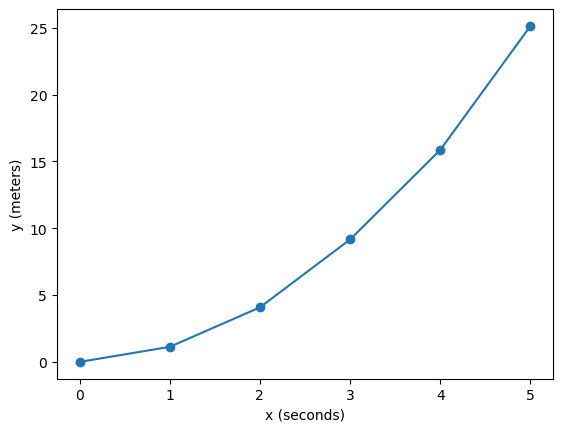

In [8]:
plt.plot(recorded_data['x']['values'], recorded_data['y']['values'], marker='o')
plt.xlabel(f"x ({recorded_data['x']['unit']})")
plt.ylabel(f"y ({recorded_data['y']['unit']})")

Now we see the recorded data, where `y` (in units of meters) is recorded as a function of `x` (in units of seconds). DataDicts are, at their heart, Python dictionaries, so they can be saved just like any other dictionary. However, because taking a measurement and saving data is so integral to any laboratory workflow, labcore provides convenient functions to run a sweep and save the data in one go.

The function {py:meth}`run_and_save_sweep <labcore.measurement.storage.run_and_save_sweep>` does just that, saving the data to an HDF5 file with all the relevant metadata. It requires a filepath where the data is saved, which uses a relative path from the current working directory. In our case, the data directory will just be `data/`.

In [9]:
loc, _ = run_and_save_sweep(sweep, data_dir="data", name="simple_sweep")
print(f"Data saved to: {loc}")

Data saved to: data/2026-02-03/2026-02-03T143006_20c3b3ee-simple_sweep


### Loading data from storage

Labcore provides functions to load data back from storage. Here, we load the data we just saved as an xarray Dataset, which is a useful data structure for working with multi-dimensional labeled data. Printing the data shows the dataset's structure. It's straightforward to access the variables and their values.

<xarray.Dataset> Size: 96B
Dimensions:  (x: 6)
Coordinates:
  * x        (x) float64 48B 0.0 1.0 2.0 3.0 4.0 5.0
Data variables:
    y        (x) float64 48B -0.1226 1.047 3.834 9.059 15.95 25.02
Attributes:
    raw_data_folder:  /Users/oliverwolff/Documents/labcore/docs/first_steps/d...
    raw_data_fn:      data/2026-02-03/2026-02-03T143006_20c3b3ee-simple_sweep...


Text(0, 0.5, 'y (meters)')

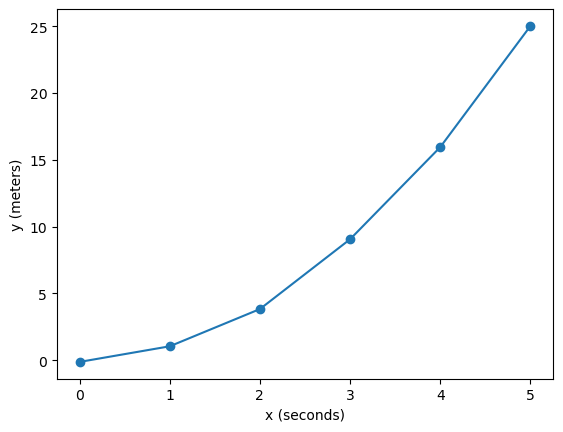

In [10]:
from labcore.data.datadict_storage import load_as_xr

data = load_as_xr(loc)
print(data)

x = data['x'].values
y = data['y'].values

plt.plot(x, y, marker='o')
plt.xlabel('x (seconds)')
plt.ylabel('y (meters)')

## Combining sweeps

### Nesting sweeps

Say we performed a particularly noisy measurement and would like to take the data many times, averaging the results. We need to add a new axis to sweep over, this time called `repetition`. This will keep the raw data from each iteration of the measurement.

Sweeps can be combined in several different ways. For this, we'll nest the sweep: for each value of `repetition`, we perform the original sweep over `x`. The resulting sweep structure reflects this nesting. Nesting is performed using the `@` operator.

In [11]:
rep_sweep = sweep_parameter('repetition', np.arange(10))

x = np.linspace(0, 5, 100)
def measure_noisy(x):
    return x, np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

noisy_sweep = sweep_parameter(
    'x', x,
    record_as(
        measure_noisy,
        independent('x', unit='seconds'),
        dependent('y', unit='meters')
    )
)

new_sweep = rep_sweep @ noisy_sweep
new_sweep

NestSweeps:
    array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]) as {repetition}
    ==> {repetition}
    @ array([0.        , 0.05050505, 0.1010101 , 0.15151515, 0.2020202 ,
             0.25252525, 0.3030303 , 0.35353535, 0.4040404 , 0.45454545,
             0.50505051, 0.55555556, 0.60606061, 0.65656566, 0.70707071,
             0.75757576, 0.80808081, 0.85858586, 0.90909091, 0.95959596,
             1.01010101, 1.06060606, 1.11111111, 1.16161616, 1.21212121,
             1.26262626, 1.31313131, 1.36363636, 1.41414141, 1.46464646,
             1.51515152, 1.56565657, 1.61616162, 1.66666667, 1.71717172,
             1.76767677, 1.81818182, 1.86868687, 1.91919192, 1.96969697,
             2.02020202, 2.07070707, 2.12121212, 2.17171717, 2.22222222,
             2.27272727, 2.32323232, 2.37373737, 2.42424242, 2.47474747,
             2.52525253, 2.57575758, 2.62626263, 2.67676768, 2.72727273,
             2.77777778, 2.82828283, 2.87878788, 2.92929293, 2.97979798,
             3.03030303, 3.080808

Reading the averaged data is as simple as averaging over the `repetition` dimension.

Data saved to: data/2026-02-03/2026-02-03T143007_20e0a59e-nested_sweep


Text(0, 0.5, 'y (meters)')

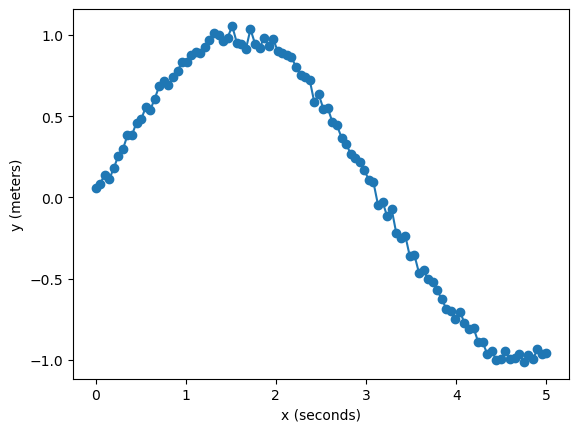

In [12]:
loc, _ = run_and_save_sweep(new_sweep, data_dir="data", name="nested_sweep")
print(f"Data saved to: {loc}")

data = load_as_xr(loc).mean(dim='repetition')
x, y = data['x'].values, data['y'].values

plt.plot(x, y, marker='o')
plt.xlabel('x (seconds)')
plt.ylabel('y (meters)')

### Appending sweeps

If we want to perform two sweeps sequentially, we can append them using the `+` operator. This does one sweep after the other.

In [13]:
def add_one(x):
    return x + 1

def multiply_by_two(x):
    return x * 2

x = np.linspace(0, 2, 3)
sweep1 = sweep_parameter(
    'x', x,
    record_as(add_one, dependent('y'))
)
sweep2 = sweep_parameter(
    'x', x,
    record_as(multiply_by_two, dependent('y'))
)

combined_sweep = sweep1 + sweep2

for data in combined_sweep:
    print(data)

{'x': np.float64(0.0), 'y': np.float64(1.0)}
{'x': np.float64(1.0), 'y': np.float64(2.0)}
{'x': np.float64(2.0), 'y': np.float64(3.0)}
{'x': np.float64(0.0), 'y': np.float64(0.0)}
{'x': np.float64(1.0), 'y': np.float64(2.0)}
{'x': np.float64(2.0), 'y': np.float64(4.0)}


### Zipping sweeps

To perform two actions in parallel, we can zip sweeps using the `*` operator. This performs both actions at each step of the sweep and is useful when different iterators are being used.

In [14]:
def add_one(x1):
    return x1, x1 + 1

def multiply_by_two(x2):
    return x2, x2 * 2

x1 = np.linspace(6, 8, 3)
x2 = np.linspace(0, 2, 3)

sweep1 = sweep_parameter(
    'x1', x1,
    record_as(add_one, independent('x1'), dependent('y1'))
)
sweep2 = sweep_parameter(
    'x2', x2,
    record_as(multiply_by_two, independent('x2'), dependent('y2'))
)

combined_sweep = sweep1 * sweep2

for data in combined_sweep:
    print(data)

{'x1': np.float64(6.0), 'y1': np.float64(7.0), 'x2': np.float64(0.0), 'y2': np.float64(0.0)}
{'x1': np.float64(7.0), 'y1': np.float64(8.0), 'x2': np.float64(1.0), 'y2': np.float64(2.0)}
{'x1': np.float64(8.0), 'y1': np.float64(9.0), 'x2': np.float64(2.0), 'y2': np.float64(4.0)}


### 2d sweeps

Say we have a measurement that depends on two independent variables, `x` and `y`. We can create a sweep that varies both parameters. Notice that the nested sweep contains two independent variables, `x` and `y`, and the dependent variable `z`.

To keep track of the parameters, we can pass some keyword arguments to the functions that print where in the sweep we currently are.

In [15]:
x = np.linspace(1, 3, 3)
y = np.linspace(1, 3, 3)

def outer_function(x, *args, **kwargs):
    if "verbose" in kwargs and kwargs["verbose"]:
        print(f"=====\nMeasuring at x={x}")
    return x

def inner_function(y, *args, **kwargs):
    if "verbose" in kwargs and kwargs["verbose"]:
        print(f"Measuring at y={y}")
    x = kwargs['x']
    return x, y, y+x

outer_sweep = sweep_parameter('x', x, outer_function)
inner_sweep = sweep_parameter(
    'y', y,
    record_as(
        inner_function,
        independent('x'),
        independent('y'),
        dependent('z')
    )
)

outer_sweep.set_options(outer_function=dict(verbose=True))
inner_sweep.set_options(inner_function=dict(verbose=False))

sweep = outer_sweep @ inner_sweep

loc, _ = run_and_save_sweep(sweep=sweep, data_dir='data', name='my_nested_sweep')
print(f'Data saved to {loc}')

=====
Measuring at x=1.0
=====
Measuring at x=2.0
=====
Measuring at x=3.0
Data saved to data/2026-02-03/2026-02-03T143009_2206b9ea-my_nested_sweep


Just like above, we can read the data by referencing the axes of the data.

Text(0, 0.5, 'y')

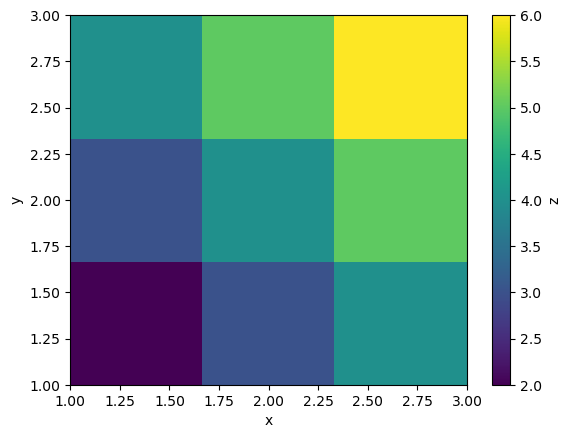

In [16]:
data = load_as_xr(loc)
x = data['x'].values
y = data['y'].values
z = data['z'].values

plt.imshow(z, extent=(x.min(), x.max(), y.min(), y.max()), origin='lower', aspect='auto')
plt.colorbar(label='z')
plt.xlabel('x')
plt.ylabel('y')

## Analyzing and visualizing data

Labcore provides some basic tools to analyze data. Much of analysis centers on fitting data, which comes from {py:mod}`labcore.analysis.fit <labcore.analysis.fit>`. The {py:class}`labcore.analysis.fit.Fit` class is a thin wrapper around [lmfit](https://lmfit.github.io/lmfit-py/), which does all of the actual fitting. We are primarily providing a standard way to pass the structured data into the optimizer. In principle, any custom fitting function can be used, if a class is provided for it. For instance, below we fit the data to a sine function.

In [17]:
def measure_data(x):
    return np.sin(0.8 * x) + 1 + np.random.normal(0, 0.1, size=x.shape)

x = np.linspace(0, 2 * np.pi, 50)
sweep = sweep_parameter('x', x, record_as(measure_data, dependent('y')))

loc, _ = run_and_save_sweep(sweep=sweep, data_dir='data', name='sine_wave')
data = load_as_xr(loc)

x = data['x'].values
y = data['y'].values

In [18]:
from labcore.analysis.fit import Fit

class SineFit(Fit):
    @staticmethod
    def model(coordinates, amplitude, frequency, phase, offset):
        return amplitude * np.sin(frequency * coordinates + phase) + offset
    
    @staticmethod
    def guess(coordinates, y):
        amplitude = (y.max() - y.min()) / 2
        offset = (y.max() + y.min()) / 2
        
        fft = np.fft.fft(y - offset)
        frequencies = np.fft.fftfreq(len(coordinates), d=(coordinates[1] - coordinates[0]))
        positive_frequencies = frequencies[frequencies > 0]
        positive_fft = fft[frequencies > 0]
        frequency = positive_frequencies[np.argmax(np.abs(positive_fft))]

        phase = 0.0
        return dict(amplitude=amplitude, frequency=frequency, phase=phase, offset=offset)

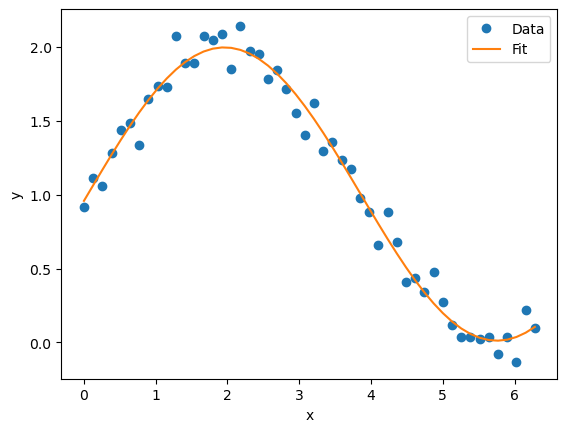

In [19]:
fit = SineFit(x, y)

fitresult = fit.run(fit)
fitcurve = fitresult.eval()

plt.plot(x, y, 'o', label='Data')
plt.plot(x, fitcurve, '-', label='Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

Labcore also provides some generic fit functions, including {py:class}`Cosine <labcore.analysis.fitfuncs.generic.Cosine>`, {py:class}`Exponential <labcore.analysis.fitfuncs.generic.Exponential>`, {py:class}`ExponentialDecay <labcore.analysis.fitfuncs.generic.ExponentialDecay>`, {py:class}`Linear <labcore.analysis.fitfuncs.generic.Linear>`, {py:class}`ExponentiallyDecayingSine <labcore.analysis.fitfuncs.generic.ExponentiallyDecayingSine>`, and {py:class}`Gaussian <labcore.analysis.fitfuncs.generic.Gaussian>`. To use these, we can simply import from {py:mod}`labcore.analysis.fitfuncs.generic <labcore.analysis.fitfuncs.generic>`.

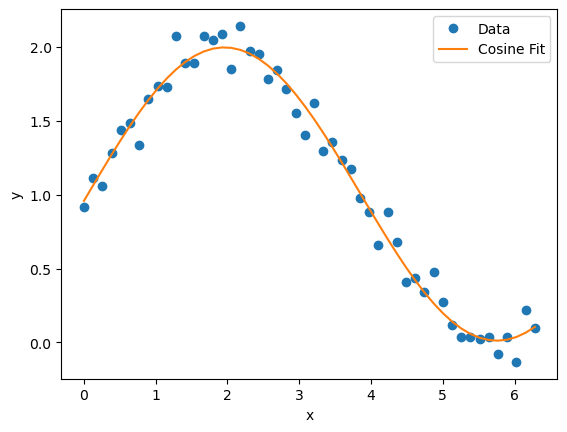

In [20]:
from labcore.analysis.fitfuncs.generic import Cosine

cosine_fit = Cosine(x, y)
fitresult = cosine_fit.run(cosine_fit)
fitcurve = fitresult.eval()
plt.plot(x, y, 'o', label='Data')
plt.plot(x, fitcurve, '-', label='Cosine Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

### Using DatasetAnalysis

To organize and save fits, plots, and analysis results, Labcore provides the {py:class}`DatasetAnalysis <labcore.analysis.analysis_base.DatasetAnalysis>` class. This class takes a file location as input and allows you to perform fits and generate plots, storing everything in an organized manner.

In [21]:
from labcore.analysis.analysis_base import DatasetAnalysis

analysis = DatasetAnalysis(datafolder=loc, name="cosine_analysis")

The class initialized by providing the data folder location and a name for the analysis. It's used as a context manager and can save analysis results and figures to an analysis directory. It defaults to a folder named "analysis" at the current working directory, but this can be changed by providing a different path.

The analysis can be retrieved later from file for further inspection or refinement.

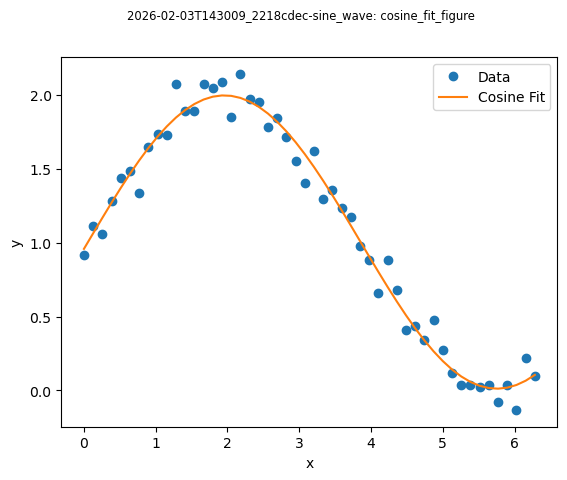

In [22]:
with analysis as a:
    fit = Cosine(x, y)
    fitresult = fit.run(fit)
    a.add(fitresult=fitresult, fit_name="cosine_fit")
    
    fitcurve = fitresult.eval()
    plt.plot(x, y, 'o', label='Data')
    plt.plot(x, fitcurve, '-', label='Cosine Fit')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    a.add_figure(name="cosine_fit_figure", fig=plt.gcf())

In [23]:
analysis.save()

data 'fitresult', type <class 'labcore.analysis.fit.FitResult'>could not be saved regularly, try pickle instead...
data 'fit_name', type <class 'str'>could not be saved regularly, try pickle instead...
data 'fitresult', type <class 'labcore.analysis.fit.FitResult'>could not be saved regularly, try pickle instead...
data 'fit_name', type <class 'str'>could not be saved regularly, try pickle instead...
